In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# Load Fashion-MNIST Dataset

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Dataset Loaded Successfully")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Loaded Successfully


In [ ]:
# Dataset Dimensions

print("Training Dataset")

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print()

print("Testing Dataset")

print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Dataset
Training Images : (60000, 28, 28)
Training Labels : (60000,)

Testing Dataset
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


In [ ]:
# Fashion-MNIST Class Names

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(class_names)

['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']


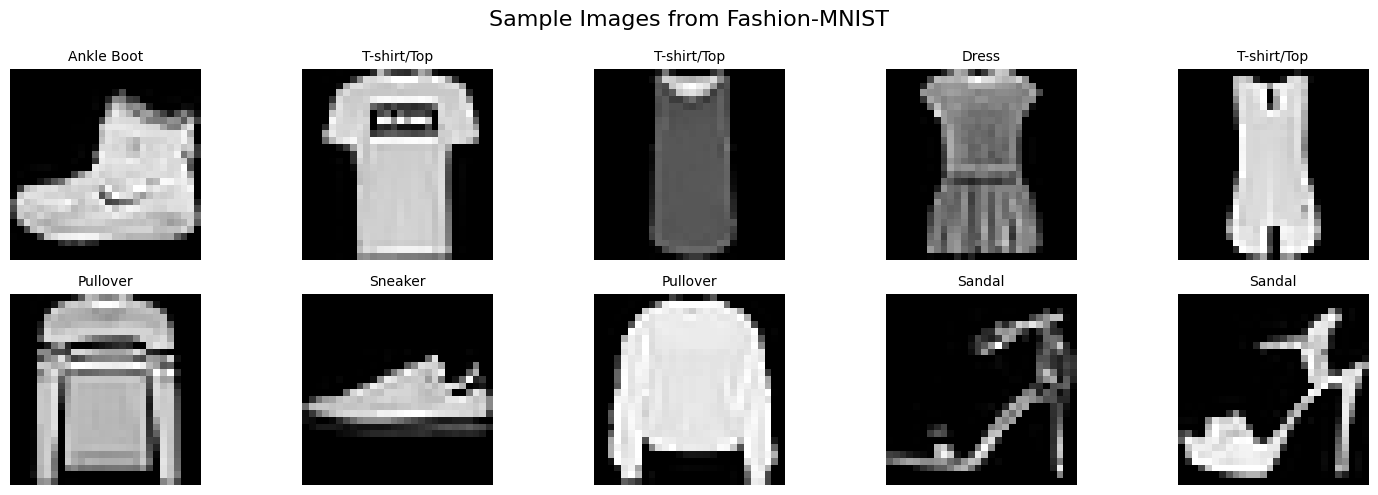

In [ ]:
# Display Sample Images

plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(class_names[y_train[i]], fontsize=10)

    plt.axis('off')

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=16)

plt.tight_layout()

plt.savefig(
    "sample_images.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

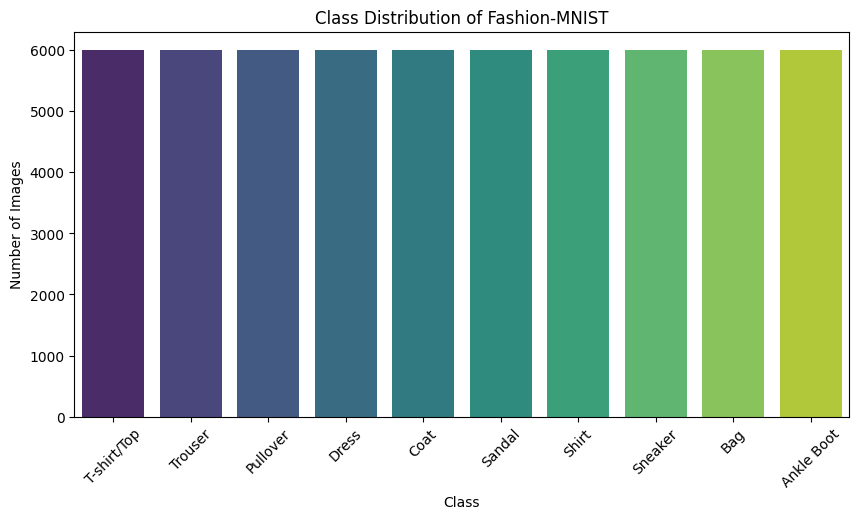

In [ ]:
# Class Distribution

class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x=class_names,
    y=class_counts.values,
    palette="viridis"
)

plt.title("Class Distribution of Fashion-MNIST")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.savefig(
    "class_distribution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Number of Images Per Class

distribution = pd.DataFrame({
    "Class": class_names,
    "Images": class_counts.values
})

distribution

,Class,Images
0,T-shirt/Top,6000
1,Trouser,6000
2,Pullover,6000
3,Dress,6000
4,Coat,6000
5,Sandal,6000
6,Shirt,6000
7,Sneaker,6000
8,Bag,6000
9,Ankle Boot,6000


In [ ]:
# Tensor Shapes Before Preprocessing

print("Before Preprocessing")

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Before Preprocessing
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)
Training Labels : (60000,)
Testing Labels  : (10000,)


In [ ]:
# Flatten Images

X_train_flat = X_train.reshape(X_train.shape[0], 28*28)
X_test_flat = X_test.reshape(X_test.shape[0], 28*28)

print("Images Flattened Successfully")

Images Flattened Successfully


In [ ]:
# Normalize Pixel Values

X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

print("Pixel Values Normalized")

Pixel Values Normalized


In [ ]:
# One-Hot Encoding

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Labels One-Hot Encoded")

Labels One-Hot Encoded


In [ ]:
# Tensor Shapes After Preprocessing

print("After Preprocessing")

print("Training Images :", X_train_flat.shape)
print("Testing Images  :", X_test_flat.shape)

print()

print("Training Labels :", y_train_cat.shape)
print("Testing Labels  :", y_test_cat.shape)

After Preprocessing
Training Images : (60000, 784)
Testing Images  : (10000, 784)

Training Labels : (60000, 10)
Testing Labels  : (10000, 10)


In [ ]:
# Verify Pixel Range

print("Minimum Pixel Value :", X_train_flat.min())
print("Maximum Pixel Value :", X_train_flat.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


In [ ]:
# One-Hot Encoding Example

print("Original Label      :", y_train[0])
print("One-Hot Encoded     :", y_train_cat[0])

Original Label      : 9
One-Hot Encoded     : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
# Import Required Modules

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Build the MLP Model

model = Sequential([

    # Input Layer
    Dense(128,
          activation='relu',
          input_shape=(784,),
          name="Hidden_Layer_1"),

    # Hidden Layer
    Dense(64,
          activation='relu',
          name="Hidden_Layer_2"),

    # Output Layer
    Dense(10,
          activation='softmax',
          name="Output_Layer")
])

print("MLP Model Created Successfully!")

MLP Model Created Successfully!


In [ ]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

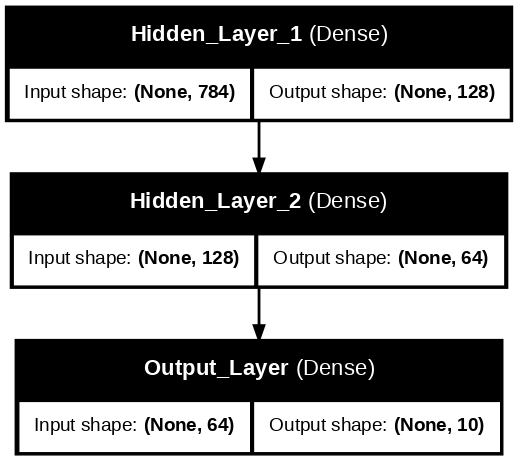

In [ ]:
# Display Model Architecture

from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

In [ ]:
# Display Layer Details

for i, layer in enumerate(model.layers):

    print(f"Layer {i+1}")

    print("Name       :", layer.name)
    print("Type       :", layer.__class__.__name__)
    print("Activation :", layer.activation.__name__)

Layer 1
Name       : Hidden_Layer_1
Type       : Dense
Activation : relu
Layer 2
Name       : Hidden_Layer_2
Type       : Dense
Activation : relu
Layer 3
Name       : Output_Layer
Type       : Dense
Activation : softmax


In [ ]:
# Compile the MLP Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [ ]:
# Train the MLP Model

history = model.fit(
    X_train_flat,
    y_train_cat,
    validation_data=(X_test_flat, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8226 - loss: 0.4966 - val_accuracy: 0.8478 - val_loss: 0.4183
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8663 - loss: 0.3695 - val_accuracy: 0.8596 - val_loss: 0.3835
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8763 - loss: 0.3354 - val_accuracy: 0.8668 - val_loss: 0.3688
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8845 - loss: 0.3118 - val_accuracy: 0.8754 - val_loss: 0.3519
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8908 - loss: 0.2937 - val_accuracy: 0.8663 - val_loss: 0.3771
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8957 - loss: 0.2810 - val_accuracy: 0.8761 - val_loss: 0.3451
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.8986 - loss: 0.2662 - val_accuracy: 0.8787 - val_loss: 0.3371
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9033 - loss: 0

In [ ]:
# Final Training Results

print("Training Completed Successfully")

print(f"Final Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")

print()

print(f"Final Training Loss       : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history.history['val_loss'][-1]:.4f}")

Training Completed Successfully
Final Training Accuracy   : 0.9329
Final Validation Accuracy : 0.8885

Final Training Loss       : 0.1770
Final Validation Loss     : 0.3635


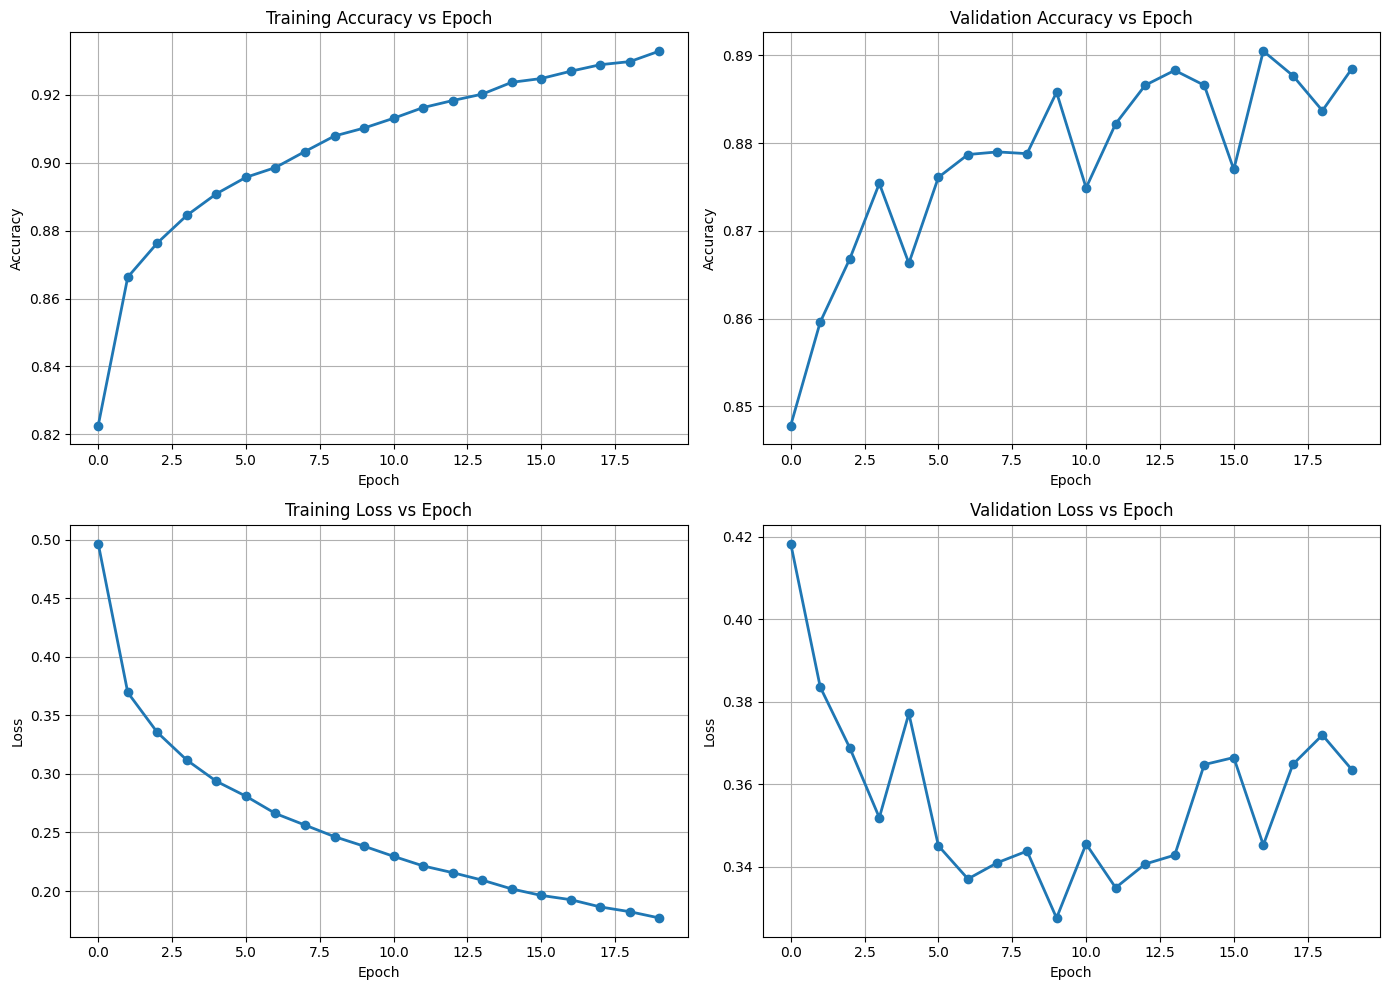

In [ ]:
# Training & Validation Curves (Single Figure)

plt.figure(figsize=(14,10))

# 1. Training Accuracy
plt.subplot(2,2,1)

plt.plot(history.history['accuracy'],
         marker='o',
         linewidth=2)

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

# 2. Validation Accuracy
plt.subplot(2,2,2)

plt.plot(history.history['val_accuracy'],
         marker='o',
         linewidth=2)

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

# 3. Training Loss
plt.subplot(2,2,3)

plt.plot(history.history['loss'],
         marker='o',
         linewidth=2)

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# 4. Validation Loss
plt.subplot(2,2,4)

plt.plot(history.history['val_loss'],
         marker='o',
         linewidth=2)

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()

# Save as EPS for Overleaf
plt.savefig(
    "training_validation_curves.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Predict Test Set

y_pred_prob = model.predict(X_test_flat)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded labels back to class labels
y_true = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# Evaluation Metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("="*50)
print("Model Evaluation")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Model Evaluation
Accuracy : 0.8885
Precision: 0.8913
Recall   : 0.8885
F1-Score : 0.8890


In [ ]:
# Classification Report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/Top       0.86      0.77      0.81      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.82      0.81      1000
       Dress       0.87      0.93      0.90      1000
        Coat       0.86      0.78      0.81      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.67      0.75      0.71      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[770   2  17  29   2   1 174   0   5   0]
 [  2 970   3  16   5   0   3   0   1   0]
 [ 15   0 820  12  71   0  81   0   1   0]
 [ 16   4  12 928  15   0  21   0   4   0]
 [  0   0  94  41 775   0  87   0   3   0]
 [  0   0   0   0   0 971   0  13   0  16]
 [ 80   0  85  34  37   0 751   0  13   0]
 [  0   0   0   0   0  12   0 966   0  22]
 [  8   0   3   8   1   5   3   2 970   0]
 [  0   0   0   1   0   5   1  29   0 964]]


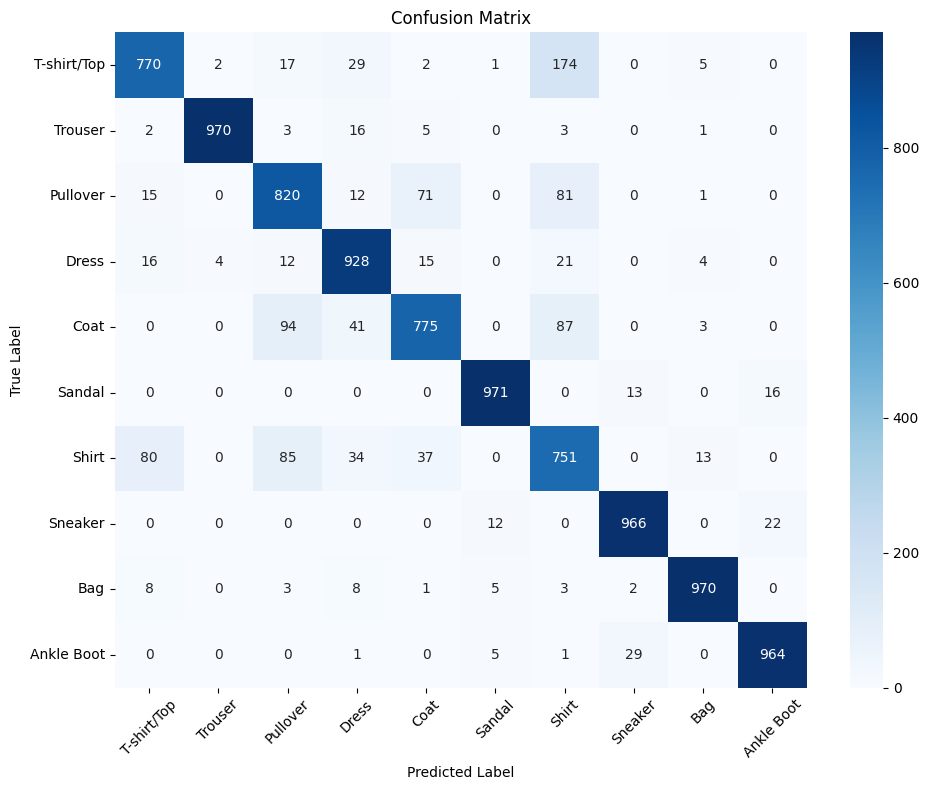

In [ ]:
# Confusion Matrix Plot

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

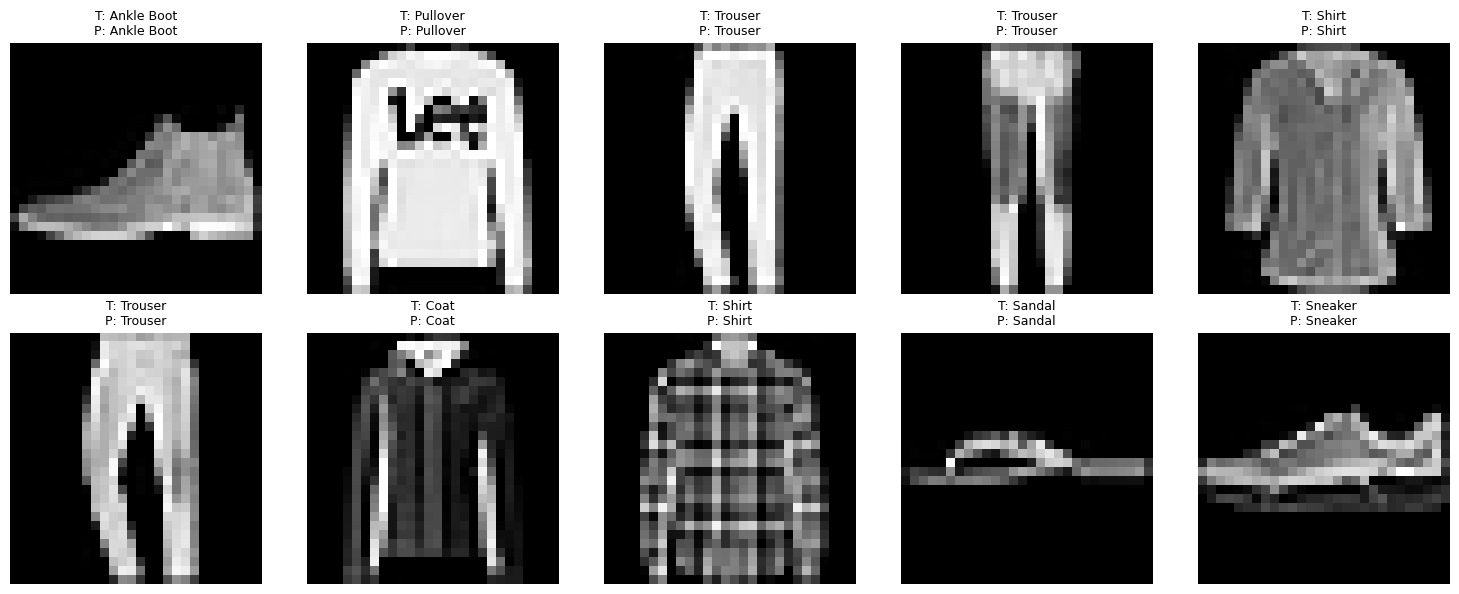

In [ ]:
# Display Sample Predictions

plt.figure(figsize=(15,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap='gray')

    plt.title(
        f"T: {class_names[y_true[i]]}\nP: {class_names[y_pred[i]]}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd

In [ ]:
def create_model(neurons1=128,
                 neurons2=64,
                 learning_rate=0.001):

    model = Sequential()

    model.add(Dense(neurons1,
                    activation='relu',
                    input_shape=(784,)))

    model.add(Dense(neurons2,
                    activation='relu'))

    model.add(Dense(10,
                    activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
#HyperParameter Search Space
param_grid = {
    "neurons1": [64, 128],
    "neurons2": [32, 64],
    "learning_rate": [0.001, 0.01],
    "batch_size": [32, 64],
    "epochs": [5, 10]
}

In [ ]:
#5fold cross validation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

best_accuracy = 0
best_params = None

results = []

for params in ParameterGrid(param_grid):

    fold_scores = []

    print("\nTesting:", params)

    for train_index, val_index in kfold.split(X_train_flat):

        X_train_fold = X_train_flat[train_index]
        X_val_fold = X_train_flat[val_index]

        y_train_fold = y_train_cat[train_index]
        y_val_fold = y_train_cat[val_index]

        model = create_model(
            neurons1=params["neurons1"],
            neurons2=params["neurons2"],
            learning_rate=params["learning_rate"]
        )

        model.fit(
            X_train_fold,
            y_train_fold,
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=0
        )

        predictions = model.predict(
            X_val_fold,
            verbose=0
        )

        predictions = np.argmax(predictions, axis=1)
        actual = np.argmax(y_val_fold, axis=1)

        acc = accuracy_score(actual, predictions)

        fold_scores.append(acc)

    mean_accuracy = np.mean(fold_scores)

    results.append({
        "Parameters": params,
        "Accuracy": mean_accuracy
    })

    print("Mean Accuracy:", mean_accuracy)

    if mean_accuracy > best_accuracy:

        best_accuracy = mean_accuracy
        best_params = params


Testing: {'batch_size': 32, 'epochs': 5, 'learning_rate': 0.001, 'neurons1': 64, 'neurons2': 32}
Mean Accuracy: 0.8760166666666667

Testing: {'batch_size': 32, 'epochs': 5, 'learning_rate': 0.001, 'neurons1': 64, 'neurons2': 64}
Mean Accuracy: 0.8734

Testing: {'batch_size': 32, 'epochs': 5, 'learning_rate': 0.001, 'neurons1': 128, 'neurons2': 32}
Mean Accuracy: 0.8778166666666667

Testing: {'batch_size': 32, 'epochs': 5, 'learning_rate': 0.001, 'neurons1': 128, 'neurons2': 64}
Mean Accuracy: 0.8794833333333333

Testing: {'batch_size': 32, 'epochs': 5, 'learning_rate': 0.01, 'neurons1': 64, 'neurons2': 32}
Mean Accuracy: 0.8512333333333334

Testing: {'batch_size': 32, 'epochs': 5, 'learning_rate': 0.01, 'neurons1': 64, 'neurons2': 64}
Mean Accuracy: 0.8534166666666667

Testing: {'batch_size': 32, 'epochs': 5, 'learning_rate': 0.01, 'neurons1': 128, 'neurons2': 32}
Mean Accuracy: 0.8538333333333334

Testing: {'batch_size': 32, 'epochs': 5, 'learning_rate': 0.01, 'neurons1': 128, 'neuro

In [ ]:
print("Best Hyperparameters")

print(best_params)

print("\nBest Cross Validation Accuracy:")

print(best_accuracy)

Best Hyperparameters
{'batch_size': 64, 'epochs': 10, 'learning_rate': 0.001, 'neurons1': 128, 'neurons2': 64}

Best Cross Validation Accuracy:
0.8875333333333334


In [ ]:
optimized_model = create_model(
    neurons1=best_params["neurons1"],
    neurons2=best_params["neurons2"],
    learning_rate=best_params["learning_rate"]
)

history = optimized_model.fit(
    X_train_flat,
    y_train_cat,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8119 - loss: 0.5312 - val_accuracy: 0.8552 - val_loss: 0.4079
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8628 - loss: 0.3820 - val_accuracy: 0.8452 - val_loss: 0.4270
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8742 - loss: 0.3427 - val_accuracy: 0.8687 - val_loss: 0.3578
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8826 - loss: 0.3186 - val_accuracy: 0.8800 - val_loss: 0.3417
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8907 - loss: 0.2995 - val_accuracy: 0.8810 - val_loss: 0.3368
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8945 - loss: 0.2837 - val_accuracy: 0.8819 - val_loss: 0.3286
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8983 - loss: 0.2754 - val_accuracy: 0.8831 - val_loss: 0.3316
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9019 - loss: 0.2613 - val_accuracy: 0.

In [ ]:
loss, optimized_accuracy = optimized_model.evaluate(
    X_test_flat,
    y_test_cat,
    verbose=0
)

print("Optimized Test Accuracy :", optimized_accuracy)
print("Optimized Test Loss :", loss)

Optimized Test Accuracy : 0.8802000284194946
Optimized Test Loss : 0.3494807481765747


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Baseline MLP", "Optimized MLP"],
    "Accuracy": [accuracy, optimized_accuracy]
})

comparison

,Model,Accuracy
0,Baseline MLP,0.8885
1,Optimized MLP,0.8802


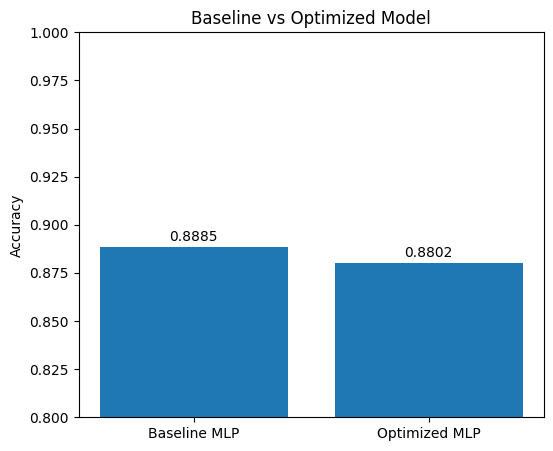

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Baseline vs Optimized Model")
plt.ylabel("Accuracy")
plt.ylim(0.80, 1.00)

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(i, value + 0.003, f"{value:.4f}", ha="center")

plt.show()

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
).head(10)

,Parameters,Accuracy
27,"{'batch_size': 64, 'epochs': 10, 'learning_rat...",0.887533
26,"{'batch_size': 64, 'epochs': 10, 'learning_rat...",0.887367
9,"{'batch_size': 32, 'epochs': 10, 'learning_rat...",0.885100
11,"{'batch_size': 32, 'epochs': 10, 'learning_rat...",0.884867
10,"{'batch_size': 32, 'epochs': 10, 'learning_rat...",0.883583
8,"{'batch_size': 32, 'epochs': 10, 'learning_rat...",0.881750
24,"{'batch_size': 64, 'epochs': 10, 'learning_rat...",0.881333
25,"{'batch_size': 64, 'epochs': 10, 'learning_rat...",0.880183
3,"{'batch_size': 32, 'epochs': 5, 'learning_rate...",0.879483
2,"{'batch_size': 32, 'epochs': 5, 'learning_rate...",0.877817


In [ ]:
#Additional Exercise
#MLP Model for XOR Gate
# XOR Dataset

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

In [ ]:
#Model
XORmodel = Sequential()

# Hidden Layer
XORmodel.add(Dense(4,
                activation='relu',
                input_shape=(2,)))

# Output Layer
XORmodel.add(Dense(1,
                activation='sigmoid'))

XORmodel.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

XORmodel.summary()

Model: "sequential_164"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_487 (Dense)               │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_488 (Dense)               │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = XORmodel.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

In [ ]:
predictions = XORmodel.predict(X)

print("Predictions:\n")

for i in range(len(X)):
    print(
        f"Input: {X[i]}",
        f"Expected: {int(y[i][0])}",
        f"Predicted: {predictions[i][0]:.4f}",
        f"Rounded: {int(predictions[i][0] > 0.5)}"
    )

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()